## Librerías

In [1]:
import sys
import glob
print(sys.executable)  # Verifica que apunte a parkinson_env

c:\Users\Jeison\AppData\Local\Programs\Python\Python312\python.exe


In [ ]:
! pip install antspynet
! pip install hd-bet
!{sys.executable} -m pip install nilearn SimpleITK antspyx tqdm ipywidgets

In [11]:
import glob
from pathlib import Path
from typing import List, Union

import numpy as np
import pandas as pd
import nibabel as nib
from nilearn.image import resample_img
from pathlib import Path
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import ants
import antspynet
#from evaluate import get_diff_img
# import preprocessing as pp_utils # ----------------------
import SimpleITK as sitk
from ipywidgets import interact, VBox, HBox, HTML
import os
import ants

## **Resampling de imagenes**
Funciones de estandarización de las resoluciones de las imagenes

<b>Flujo general</b>

- Estandarización resolución a 1mm³
- Eliminación del cráneo, dejando solo el cerebro
- Corrección de iluminación desigual del escáner
- Alinear cerebro al MNI152
- Deformar MNI152 hacia el cerebro
- Llevar el atlas al espacio del paciente

<h3>Resampling a 1mm</h3>
Tenemos que no todas las imagenes presentan el mismo tamaño por diferentes circunstancias, así que se estadariza a cada voxel a 1mm x 1mm x 1mm. Con el fin de que cada cerebro sea comparable entre si.

In [4]:
def resampling(root_path, adc_path=None, results_dir=None, ncct_path=None):

    results_dir.mkdir(exist_ok=True)
    
    '''def resample_to_isotropic(nib_image, target_voxel_size=(1.0, 1.0, 1.0), interpolation='linear'):
        """
        Resamplea una imagen NIfTI a resolución isotrópica 1mm³ usando nilearn.
        """
        target_affine = np.diag(list(target_voxel_size) + [1])
        resampled = resample_img(
            nib_image,
            target_affine=target_affine,
            interpolation=interpolation
        )
        return resampled.get_fdata(), resampled.affine, resampled.header'''
    
    ######################################################################################################
    def resample_to_isotropic(nib_image, target_voxel_size=(1.0, 1.0, 1.0), interpolation='linear'):
        """
        Resamplea una imagen NIfTI a resolución isotrópica 1mm³ usando nilearn.
        """
        # Conservar la orientación original, solo cambiar el tamaño del voxel
        affine = nib_image.affine
        target_affine = np.copy(affine)
        
        # Escalar cada columna del affine al tamaño de voxel deseado
        for i in range(3):
            col_norm = np.linalg.norm(affine[:3, i])
            target_affine[:3, i] = affine[:3, i] / col_norm * target_voxel_size[i]
        
        resampled = resample_img(
            nib_image,
            target_affine=target_affine,
            interpolation=interpolation
        )
        return resampled.get_fdata(), resampled.affine, resampled.header
    ######################################################################################################
    
    if adc_path is not None:
        # Detecta la extensión (.nii o .nii.gz)
        adc_extension = "".join(adc_path.suffixes)
        print("adc_extension:", adc_extension)
        adc_filename = adc_path.name.replace(adc_extension, "")
        print("adc_filename:", adc_filename)

        # Carga la imagen cruda
        adc = nib.load(adc_path)
        print("file loaded")

        # Aplica el resampling
        '''arr - voxeles | aff - ubicacion de cada voxel | header - metadata'''
        adc_arr, adc_aff, adc_header = resample_to_isotropic(adc, target_voxel_size=(1.0, 1.0, 1.0), interpolation='linear')
        print("resampled")

        # Crea nueva imagen con los datos resampled
        adc_resampled_img = nib.Nifti1Image(adc_arr, adc_aff, adc_header)
        adc_resampled_path = results_dir / f"{adc_filename}_resampled{adc_extension}"

        # Guarda con nombre *_resampled.nii
        nib.save(adc_resampled_img, adc_resampled_path)
        print(f"saved: {adc_resampled_path}")
    else:
        adc_resampled_path = None

    if ncct_path is not None:
        ncct_extension = "".join(ncct_path.suffixes)
        ncct_filename = ncct_path.name.replace(ncct_extension, "")  

        ncct = nib.load(ncct_path)
        print("NCCT file loaded")

        ncct_arr, ncct_aff, ncct_header = resample_to_isotropic(ncct, target_voxel_size=(1.0, 1.0, 1.0), interpolation='linear')
        print("resampled")

        ncct_resampled_img = nib.Nifti1Image(ncct_arr, ncct_aff, ncct_header)
        ncct_resampled_path = results_dir / f"{ncct_filename}_resampled{ncct_extension}"
        nib.save(ncct_resampled_img, ncct_resampled_path)
        print(f"saved: {ncct_resampled_path}")
    else:
        ncct_resampled_path = None

    if adc_path is None and ncct_path is None:
        print("No ADC or NCCT path was given")
        return None, None, None
    elif adc_path is None:
        return None, ncct_resampled_path
    elif ncct_path is None:
        return adc_resampled_path, None

    return adc_resampled_path, ncct_resampled_path

<h3>Elminación del craneo de las imagenes</h3> - (es el que necesita el dichoso archivo preprocessing pero no lo encuentro xd)

FUNCION SIN USAR EL PP.UTILS

In [7]:
def skull_stripping(adc_resampled_path, results_dir):
    print("inside skull stripping function")
    
    img = ants.image_read(str(adc_resampled_path))
    
    # Skull stripping con antspynet (deep learning)
    brain_mask = antspynet.brain_extraction(img, modality="t1")
    brain_extracted = img * brain_mask
    
    # Guardar imagen sin cráneo
    out_img_path = str(results_dir / (Path(adc_resampled_path).stem + "_brain_extracted.nii.gz"))
    ants.image_write(brain_extracted, out_img_path)
    
    # Guardar máscara
    out_mask_path = str(results_dir / (Path(adc_resampled_path).stem + "_brain_mask.nii.gz"))
    ants.image_write(brain_mask, out_mask_path)
    
    print(f"saved on: {results_dir}")
    return out_img_path, out_mask_path

In [6]:
def skull_stripping(adc_resampled_path, results_dir):
    print("inside skullstripping function")

    # Herramienta de FreeSurfer basada en deep learning entrenada específicamente para eliminar el cráneo de imágenes MRI.
    adc_output_img_path, adc_output_bm_path = pp_utils.synthstrip_wrapper(
        input_img_path= adc_resampled_path,
        results_dir= Path(results_dir),
        write_brain_mask= True,
        verbose=True,
        )

    print("saved on: ", results_dir)
    # Se retorna la ruta de la imagen con el cráneo eliminado y la máscara del cerebro (1=cerebro, 0=no cerebro)
    return adc_output_img_path, adc_output_bm_path

- funcion **ncct_mprage, mprage_skull_stripping** está en vista de descartado porque lo que hace es a una CT convertirlas a un formato similar a MRI
CT scan  →  SynthSR  →  imagen sintética tipo MRI (MPRAGE)

<h3>Registro rígido</h3>
Tranformacion sin deformar el cerebro con la referencia: MNI152

In [8]:
def ants_rigid_registration(template_path, mri_path, results_dir, modality):
    #perform the rigid registration from the subject to the template
    
    print("RIGID REGISTRATION: from subject to template:")
    print("starting registration")
    print("reading the template")

    # Carga el template MNI152 (la referencia fija)
    template_image = ants.image_read(template_path) 
    print("reading the mri")

    # Carga la MRI del paciente (la que se va a mover)
    mri_image = ants.image_read(mri_path)     
    
    # Calcula la transformación necesaria para alinear la MRI del paciente con el template usando 
    # una transformación rígida (rotación y traslación, sin escalado ni deformación)
    registration = ants.registration(
        fixed=template_image, 
        moving=mri_image,
        type_of_transform='Rigid'
        ) 
    
    # Aplica la transformación
    print("applying the transformation")
    warped_image = ants.apply_transforms(
        fixed=template_image, 
        moving=mri_image,
        transformlist=registration['fwdtransforms'])
    print("RIGID transformation applied") 
    
    if modality == "mri":
        print("modality is mri")
        mri_file_name = mri_path.split("/")[-1]
        prefix = mri_file_name.split(".")[0]
        output_rigid_path = os.path.join(results_dir, prefix + '_rigid_registered.nii.gz')
        
    else:
        mri_file_name = mri_path.split("/")[-1]
        print("mri_file_name", mri_file_name)
        current_file_name = mri_file_name.split(".")[0]
        final_name = current_file_name + "_rigid_registered.nii.gz"
        output_rigid_path = os.path.join(results_dir, final_name)

    # Guarda como *_rigid_registered.nii.gz
    ants.image_write(warped_image, output_rigid_path)
    print("saved at", output_rigid_path)
    return output_rigid_path

<h3>Registro Elástico</h3>
El registro rígido alineó el cerebro al MNI152 con rotación y traslación. Pero algunos cerebros tienen más pliegues, otros menos, por ejemplo el putamen de una persona no tiene exactamente la misma forma que el de otra. El registro elástico va más allá y deforma el cerebro para que se ajuste mejor.<br>

- Cada cerebro queda con su cerebro de referencia deformado para no perder la anatomia de cada cerebro.

In [9]:
def ants_elastic_registration(template_path, output_rigid_path, saved_files):
    #perform the elastic registration from the template to the subject
    print("ELASTIC REGISTRATION: from template to subject:")
    print("starting registration")
    print("reading the template")
    template_image = ants.image_read(template_path) 
    print("reading the mri")
    rigid_image = ants.image_read(output_rigid_path)     
    
    registration = ants.registration(
        fixed=rigid_image, 
        moving=template_image,
        type_of_transform='SyN'
        ) 
    
    # Apply the transformation to the moving image
    print("applying the transformation")
    warped_image = ants.apply_transforms(
        fixed=rigid_image, 
        moving=template_image,
        transformlist=registration['fwdtransforms']
        )
    print("ELASTIC transformation applied") 
    
    mri_file_name = output_rigid_path.split("/")[-1]
    prefix = mri_file_name.split(".")[0]
    
    # Se guarda el atlas deformado por paciente como *_elastic_registered.nii.gz
    output_elastic_path = os.path.join(saved_files, prefix + '_elastic_registered.nii.gz')
        
    ants.image_write(warped_image, output_elastic_path)
    print("saved at", output_elastic_path)
    return output_elastic_path

<h3>Deformación del atlas</h3>

Se toma el atlas original y lo deforma para que encaje perfectamente sobre el cerebro del paciente<br>

- MNI152 es como una foto satelital — Ayuda a orientarte y alinearte
- Atlas es como el mapa de barrios — Dice qué zona es cada cosa

Es el **atlas deformado específicamente para ese paciente**. Cada voxel ya no dice una intensidad de MRI sino un **número de región**:
```
0  → fondo
4  → tálamo izquierdo
5  → caudado izquierdo
6  → putamen izquierdo
8  → brain-stem
...

In [10]:
def ants_warp(atlas_path, output_elastic_path, to_save):
    
    print("==== **SUBCORTICAL WARP** ====")
    #here the subcortical atlas is warped to the elastic warped image

    # Carga el atlas estándar 
    print("reading the atlas")
    atlas_image = ants.image_read(atlas_path)

    # Carga el cerebro del paciente ya registrado
    print("atlas loaded")
    print("loading the elastic warped image")
    elastic_warped_image = ants.image_read(output_elastic_path)

    # Calcula la deformación del atlas hacia el cerebro
    print("defining the registration")                
    registration = ants.registration(
        fixed=elastic_warped_image, 
        moving=atlas_image,
        type_of_transform='SyN'
        )

    print("registration defined")

    # Aplica esa deformación al atlas para que quede alineado con el cerebro del paciente
    print("applying the transformation")
    warped_image = ants.apply_transforms(
        fixed=elastic_warped_image, 
        moving=atlas_image,
        transformlist=registration['fwdtransforms']
        )
    print("TRANSFORMATION applied")   
    
    mri_file_name = output_elastic_path.split("/")[-1]
    prefix = mri_file_name.split(".")[0]
    output_final_registered_path = os.path.join(to_save, prefix + '_final.nii.gz')
    
    # Guarda como *_final.nii.gz
    ants.image_write(warped_image, output_final_registered_path)
    print("saved at", output_final_registered_path)
    
    return output_final_registered_path

<h3> Correción de bias field </h3>
Correción de iluminación desigual causada por imperfecciones del escáner.

In [11]:
def field_bias_correction(raw_img_path, results_dir, modality):
    
    #reading the mri image in nii or ni.gz format

    # Carga la imagen
    print("reading the raw image")
    raw_img_sitk = sitk.ReadImage(raw_img_path, sitk.sitkFloat32) 
    #getting the array
    raw_img_sitk_arr = sitk.GetArrayFromImage(raw_img_sitk) #3

    #==== creating the brain mask ==== 

    # Rescala intensidades a 0-255 para crear la máscara
    print("rescaling the intesities 0-255")
    transformed = sitk.RescaleIntensity(raw_img_sitk, 0, 255) #1

    # Crea una máscara binaria de la cabeza (separa cabeza del fondo)
    print("getting the brain mask")
    transformed = sitk.LiThreshold(transformed,0,1) #2
    head_mask = transformed
    
    #=========== applying the bias field correction ===========
    #factor de encogemiento de la img original (menos costo computacional)
    # Reduce la imagen a 1/4 del tamaño
    shrinkFactor = 4 
    inputImage = raw_img_sitk

    #applying the shrink factor
    print("applying the shrink factor")
    inputImage = sitk.Shrink( raw_img_sitk, [ shrinkFactor ] * inputImage.GetDimension() )
    #the same factor to the brain mask
    maskImage = sitk.Shrink( head_mask, [ shrinkFactor ] * inputImage.GetDimension() ) #3

    # Calcula el bias field sobre la imagen reducida
    #creating the biasFieldCorrector object
    bias_corrector = sitk.N4BiasFieldCorrectionImageFilter()
    #applying the bias correction to the shrinked versions
    print("applying the bias correction to the shrinked versions")
    corrected = bias_corrector.Execute(inputImage, maskImage)
    
    # Aplica la corrección a la imagen ORIGINAL (tamaño completo)
    # logaritmic bias field
    log_bias_field = bias_corrector.GetLogBiasFieldAsImage(raw_img_sitk) 
    #escale in the original image version
    print("escale in the original image version")
    corrected_image_full_resolution = raw_img_sitk / sitk.Exp( log_bias_field )
    
    #saving the results
    # Save the output
    print("saving the results")
    to_save = results_dir
    if modality == "mri":
        print("raw_img_path: ", raw_img_path)
        mri_file_name = raw_img_path.split("/")[-1]
        print("mri_file_name", mri_file_name)
        prefix = mri_file_name.split("-")[0]
        print("prefix", prefix)
        output_warped_path = os.path.join(to_save, prefix + '_resampled_brain_extracted_bias_corrected.nii.gz')
        print("output_warped_path", output_warped_path)
    else:
        mri_file_name = raw_img_path.split("/")[-1]
        print("mri_file_name", mri_file_name)
        current_file_name = mri_file_name.split(".")[0]
        final_name = current_file_name + "_bias_corrected.nii.gz"
        output_warped_path = os.path.join(to_save, final_name)
    
    sitk.WriteImage(corrected_image_full_resolution, output_warped_path)
    
    print("corrected image saved in: ", output_warped_path)
    
    return output_warped_path

## **Preprocesamiento de las imagenes**

<h3>Definición de ubicación de los datos mri y spect</h3>

In [12]:
root_path = Path(r"D:\DESCARGAS\ctrl_pd_mri_spect")
group = "parkinson"
modality = "mri"

current_root_path = os.path.join(root_path, group, modality)
cases = sorted(os.listdir(current_root_path))
print(f"Casos encontrados: {len(cases)}")
print(cases)

Casos encontrados: 117
['3102', '3105', '3107', '3108', '3111', '3113', '3116', '3118', '3119', '3120', '3122', '3123', '3124', '3125', '3126', '3127', '3128', '3129', '3130', '3131', '3132', '3134', '3150', '3154', '3166', '3167', '3168', '3173', '3174', '3175', '3176', '3178', '3179', '3181', '3182', '3184', '3185', '3190', '3305', '3307', '3308', '3309', '3311', '3314', '3321', '3322', '3323', '3325', '3327', '3328', '3332', '3352', '3354', '3359', '3360', '3364', '3365', '3366', '3367', '3371', '3372', '3373', '3374', '3375', '3376', '3377', '3378', '3380', '3383', '3385', '3386', '3387', '3392', '3552', '3556', '3557', '3558', '3559', '3564', '3567', '3574', '3575', '3577', '3584', '3585', '3586', '3587', '3588', '3589', '3591', '3592', '3593', '3752', '3789', '3808', '3823', '3824', '3825', '3826', '3827', '3828', '3829', '3830', '3831', '3832', '3833', '3834', '3835', '3837', '3838', '3863', '3866', '3867', '4020', '4025', '4033', '41184']


In [23]:
case = "3102"

# MRI
mri_path_dir = os.path.join(root_path, group, "mri", case)
mri_files = [f for f in os.listdir(mri_path_dir) if f.endswith(".nii") or f.endswith(".nii.gz")]
mri_path = os.path.join(mri_path_dir, mri_files[0])
print(f"MRI: {mri_path}")

# SPECT
spect_path_dir = os.path.join(root_path, group, "spect", case)
spect_files = [f for f in os.listdir(spect_path_dir) if f.endswith(".nii") or f.endswith(".nii.gz")]
spect_path = os.path.join(spect_path_dir, spect_files[0])
print(f"SPECT: {spect_path}")

MRI: D:\DESCARGAS\ctrl_pd_mri_spect\parkinson\mri\3102\PPMI_3102_MR_T1-anatomical_Br_20140123143920185_S193426_I406748.nii
SPECT: D:\DESCARGAS\ctrl_pd_mri_spect\parkinson\spect\3102\PPMI_3102_NM_Reconstructed_DaTSCAN_Br_20140404125209944_1_S197893.nii.gz


<h3> Aplicación de preprocesamiento - primeros pasos </h3>
Se aplican para las imagenes MRI y SPECT los preprocesamiento de Resampling y quitado del craneo (solo para MRI)

In [24]:
# Rutas generales
output_path = Path(r"D:\DESCARGAS\replica\preprocesamiento_mri\output") # carpeta donde se guardarán los resultados
atlas_path = Path(r"D:\DESCARGAS\replica\HarvardOxford-sub-maxprob-thr25-1mm.nii.gz") # atlas estándar de subcorticales
template_path = Path(r"D:\DESCARGAS\replica\MNI152_T1_1mm.nii.gz") # template estándar MNI152 para registro
error_log_path = "errores_log.txt" # archivo para registrar errores

group = "parkinson"

for modality in ["mri", "spect"]:
    print(f"\n===== Modalidad: {modality} =====")
    current_root_path = root_path / group / modality
    cases = sorted([c for c in os.listdir(current_root_path) if os.path.isdir(current_root_path / c)])

    for case in cases[:1]:  # solo el primer caso de prueba
        print(f"\n🔹 case: {case}")
        case_dir = current_root_path / case

        nii_files = [f for f in os.listdir(case_dir) if f.endswith((".nii", ".nii.gz"))]
        if not nii_files:
            print(f"⚠️ No se encontraron archivos en {case_dir}")
            continue

        mri_path = case_dir / nii_files[0]
        print(f"imagen: {mri_path}")

        results_dir = output_path / group / modality / case
        results_dir.mkdir(parents=True, exist_ok=True)

        # Paso 1: Resampling
        try:
            resampled_path, _ = resampling(case_dir, adc_path=mri_path, results_dir=results_dir)
        except Exception as e:
            with open(error_log_path, "a") as f:
                f.write(f"[Resampling Error] {case} | {modality} | {e}\n")
            continue

        # Paso 2: Skull stripping (solo MRI)
        if modality == "mri":
            try:
                skull_stripping(resampled_path, results_dir)
            except Exception as e:
                with open(error_log_path, "a") as f:
                    f.write(f"[SkullStripping Error] {case} | {modality} | {e}\n")
                continue


===== Modalidad: mri =====

🔹 case: 3102
imagen: D:\DESCARGAS\ctrl_pd_mri_spect\parkinson\mri\3102\PPMI_3102_MR_T1-anatomical_Br_20140123143920185_S193426_I406748.nii
adc_extension: .nii
adc_filename: PPMI_3102_MR_T1-anatomical_Br_20140123143920185_S193426_I406748
file loaded
resampled
saved: D:\DESCARGAS\replica\preprocesamiento_mri\output\parkinson\mri\3102\PPMI_3102_MR_T1-anatomical_Br_20140123143920185_S193426_I406748_resampled.nii
inside skull stripping function
saved on: D:\DESCARGAS\replica\preprocesamiento_mri\output\parkinson\mri\3102

===== Modalidad: spect =====

🔹 case: 3102
imagen: D:\DESCARGAS\ctrl_pd_mri_spect\parkinson\spect\3102\PPMI_3102_NM_Reconstructed_DaTSCAN_Br_20140404125209944_1_S197893.nii.gz
adc_extension: .nii.gz
adc_filename: PPMI_3102_NM_Reconstructed_DaTSCAN_Br_20140404125209944_1_S197893
file loaded
resampled
saved: D:\DESCARGAS\replica\preprocesamiento_mri\output\parkinson\spect\3102\PPMI_3102_NM_Reconstructed_DaTSCAN_Br_20140404125209944_1_S197893_resa

<h3> Aplicación de preprocesamiento - pasos de: field correction - registros - atlas </h3>

In [25]:
for modality in ["mri", "spect"]:
    print(f"\n===== Modalidad: {modality} =====")
    current_root_path = root_path / group / modality
    cases = sorted([c for c in os.listdir(current_root_path) if os.path.isdir(current_root_path / c)])

    for case in cases[:1]:  # solo el primer caso de prueba
        print(f"\n🔹 case: {case}")
        
        results_dir = output_path / group / modality / case
        files = os.listdir(results_dir)

        # Buscar la imagen correcta según modalidad
        if modality == "mri":
            nii_files = [f for f in files if f.endswith("brain_extracted.nii.gz")]
        else:
            nii_files = [f for f in files if f.endswith("resampled.nii.gz")]

        if not nii_files:
            print(f"⚠️ No se encontró imagen para {case} | {modality}")
            continue

        img_path = str(results_dir / nii_files[0])
        print(f"imagen: {img_path}")

        # Bias field correction
        try:
            new_img_path = field_bias_correction(img_path, str(results_dir), modality)
            print("bias field correction done")
        except Exception as e:
            with open(error_log_path, "a") as f:
                f.write(f"[BiasCorrection Error] {case} | {modality} | {e}\n")
            continue

        # Registro rígido
        try:
            output_rigid_path = ants_rigid_registration(str(template_path), new_img_path, str(results_dir), modality)
            print("rigid registration done")
        except Exception as e:
            with open(error_log_path, "a") as f:
                f.write(f"[RigidRegistration Error] {case} | {modality} | {e}\n")
            continue

        # Registro elástico
        try:
            output_elastic_path = ants_elastic_registration(str(template_path), output_rigid_path, str(results_dir))
            print("elastic registration done")
        except Exception as e:
            with open(error_log_path, "a") as f:
                f.write(f"[ElasticRegistration Error] {case} | {modality} | {e}\n")
            continue

        # Warp atlas
        try:
            ants_warp(str(atlas_path), output_elastic_path, str(results_dir))
            print("warp done")
        except Exception as e:
            with open(error_log_path, "a") as f:
                f.write(f"[Warp Error] {case} | {modality} | {e}\n")
            continue

print("\n - Terminado")


===== Modalidad: mri =====

🔹 case: 3102
imagen: D:\DESCARGAS\replica\preprocesamiento_mri\output\parkinson\mri\3102\PPMI_3102_MR_T1-anatomical_Br_20140123143920185_S193426_I406748_resampled_brain_extracted.nii.gz
reading the raw image
rescaling the intesities 0-255
getting the brain mask
applying the shrink factor
applying the bias correction to the shrinked versions
escale in the original image version
saving the results
raw_img_path:  D:\DESCARGAS\replica\preprocesamiento_mri\output\parkinson\mri\3102\PPMI_3102_MR_T1-anatomical_Br_20140123143920185_S193426_I406748_resampled_brain_extracted.nii.gz
mri_file_name D:\DESCARGAS\replica\preprocesamiento_mri\output\parkinson\mri\3102\PPMI_3102_MR_T1-anatomical_Br_20140123143920185_S193426_I406748_resampled_brain_extracted.nii.gz
prefix D:\DESCARGAS\replica\preprocesamiento_mri\output\parkinson\mri\3102\PPMI_3102_MR_T1
output_warped_path D:\DESCARGAS\replica\preprocesamiento_mri\output\parkinson\mri\3102\PPMI_3102_MR_T1_resampled_brain_ext

<h3> Verificación que todas las imágenes procesadas tengan las mismas dimensiones </h3>

In [28]:
# Imagen de referencia — caso 3102 MRI ya procesado
ref_path = str(output_path / "parkinson/mri/3102") 
ref_files = os.listdir(ref_path)
ref_final = [f for f in ref_files if f.endswith("registered_final.nii.gz")][0]
ref_image = sitk.ReadImage(os.path.join(ref_path, ref_final))
ref_img = sitk.GetArrayFromImage(ref_image)
ref_w, ref_h, ref_d = ref_img.shape
print(f"Dimensiones de referencia: {ref_w} x {ref_h} x {ref_d}")

# Verificar dimensiones para cada modalidad
for modality in ["mri", "spect"]:
    print(f"\n===== Modalidad: {modality} =====")
    current_root_path = root_path / group / modality
    cases = sorted([c for c in os.listdir(current_root_path) if os.path.isdir(current_root_path / c)])

    for case in cases[:1]:
        print(f"====== case ====== {case}")
        results_dir = str(output_path / group / modality / case)
        files = os.listdir(results_dir)

        # Verificar atlas deformado
        nii_files = [f for f in files if f.endswith("registered_final.nii.gz")]
        if nii_files:
            final_path = os.path.join(results_dir, nii_files[0])
            img = sitk.GetArrayFromImage(sitk.ReadImage(final_path))
            w, h, d = img.shape
            if w != ref_w or h != ref_h or d != ref_d:
                print(f"ERROR IN ATLAS: {w}x{h}x{d} vs ref {ref_w}x{ref_h}x{ref_d}")
            else:
                print(f" - Atlas OK: {w}x{h}x{d}")

        # Verificar imagen registrada rígidamente
        nii_files = [f for f in files if f.endswith("rigid_registered.nii.gz")]
        if nii_files:
            rigid_path = os.path.join(results_dir, nii_files[0])
            img = sitk.GetArrayFromImage(sitk.ReadImage(rigid_path))
            w, h, d = img.shape
            if w != ref_w or h != ref_h or d != ref_d:
                print(f"ERROR IN CASE: {w}x{h}x{d} vs ref {ref_w}x{ref_h}x{ref_d}")
            else:
                print(f" - Case OK: {w}x{h}x{d}")

print("\ndone")

Dimensiones de referencia: 182 x 218 x 182

===== Modalidad: mri =====
====== case ====== 3102
 - Atlas OK: 182x218x182
 - Case OK: 182x218x182

===== Modalidad: spect =====
====== case ====== 3102
 - Atlas OK: 182x218x182
 - Case OK: 182x218x182

done


<h3> Información detallada de un ejemplo de imagen </h3>

In [29]:
def get_nii_info(path):
    # cargar en formato sitk
    sitk_image = sitk.ReadImage(path)
    # convertir a numpy array
    img = sitk.GetArrayFromImage(sitk_image)

    img_shape = sitk_image.GetSize()
    print("some image information from nii format: \n")
    print("original spacing: ", sitk_image.GetSpacing())        # ¿qué tan grande es cada voxel?
    print("original size: ", img_shape)                         # ¿cuántos voxeles tiene la imagen?
    print("image direction: ", sitk_image.GetDirection())       # ¿hacia dónde apuntan los ejes?
    print("image origin: ", sitk_image.GetOrigin())             # ¿dónde está el cerebro en el espacio físico?
    print("image pixel type: ", sitk_image.GetPixelIDTypeAsString())
    print("pixel id value type: ", sitk_image.GetPixelIDValue())
    print("from numpy --> study dimensions: ", img.shape)
    print("min pixel value: {}, max pixel value: {}".format(img.min(), img.max())) # ¿cuál es el rango de intensidades?

    print("\nintensity in one slice:")
    id_indx = 90
    img_slice = img[:, :, id_indx]
    print("min and max pixel value in slice {}: {}, {}".format(id_indx, img_slice.min(), img_slice.max()))

    return img

# Verificar MRI
print("===== MRI =====")
mri_final = glob.glob(str(output_path / "parkinson/mri/3102/*_final.nii.gz"))[0]
get_nii_info(mri_final)

# Verificar SPECT
print("\n===== SPECT =====")
spect_final = glob.glob(str(output_path / "parkinson/spect/3102/*_final.nii.gz"))[0]
get_nii_info(spect_final)

===== MRI =====
some image information from nii format: 

original spacing:  (1.0, 1.0, 1.0)
original size:  (182, 218, 182)
image direction:  (1.0, 0.0, 0.0, 0.0, -1.0, 0.0, 0.0, 0.0, 1.0)
image origin:  (-90.0, 126.0, -72.0)
image pixel type:  32-bit float
pixel id value type:  8
from numpy --> study dimensions:  (182, 218, 182)
min pixel value: 0.0, max pixel value: 21.0

intensity in one slice:
min and max pixel value in slice 90: 0.0, 15.0

===== SPECT =====
some image information from nii format: 

original spacing:  (1.0, 1.0, 1.0)
original size:  (182, 218, 182)
image direction:  (1.0, 0.0, 0.0, 0.0, -1.0, 0.0, 0.0, 0.0, 1.0)
image origin:  (-90.0, 126.0, -72.0)
image pixel type:  32-bit float
pixel id value type:  8
from numpy --> study dimensions:  (182, 218, 182)
min pixel value: 0.0, max pixel value: 21.0

intensity in one slice:
min and max pixel value in slice 90: 0.0, 21.0


array([[[0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        ...,
        [0.        , 0.        , 0.        , ..., 1.4510987 ,
         0.65713054, 0.        ],
        [0.        , 0.        , 0.        , ..., 0.08664951,
         0.03233096, 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ]],

       [[0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        ...,
        [0.        , 0.        , 0.        , ..., 1.3148581 ,
         0.42585704, 0.01586588],
        [0. 

*_resampled.nii - Imagen cruda con resolución estandarizada a 1mm³, punto de partida <br><br>
*_resampled_brain_mask.nii.gz - Máscara binaria — 1 donde hay cerebro, 0 donde hay cráneo o fondo <br><br>
*_resampled_brain_extracted.nii.gz - Imagen con el cráneo eliminado <br><br>
*_resampled_brain_extracted_bias_corrected.nii.gz - Correción de la iluminación desigual del escáner <br><br>
*_resampled_brain_extracted_bias_corrected_rigid_registered.nii.gz - Cerebro alineado al MNI152 mediante rotación y traslación <br><br>
*_resampled_brain_extracted_bias_corrected_rigid_registered_elastic_registered.nii.gz - MNI152 deformado finamente hacia el espacio del cerebro del paciente <br><br>
*_resampled_brain_extracted_bias_corrected_rigid_registered_elastic_registered_final.nii.gz - Atlas Harvard-Oxford deformado sobre el cerebro <br><br>

## **Parcelación del atlas**

In [2]:
from nilearn import datasets
from nilearn import image as nimg
from nilearn import plotting as nplot

<h3> Carga del atlas y obtención de etiquetas </h3>

In [3]:
parcel_dir = "D:/DESCARGAS/replica"

# Cargar el atlas Harvard-Oxford
harvard_oxford = datasets.fetch_atlas_harvard_oxford(
    atlas_name='sub-maxprob-thr25-1mm', 
    data_dir=parcel_dir
)

# Obtener las etiquetas y la imagen del atlas
labels = harvard_oxford['labels']
atlas_img = harvard_oxford['maps']

# Mostrar las regiones
for label_id, label_name in enumerate(labels):
    print(f"{label_id + 1}: {label_name}")

[fetch_atlas_harvard_oxford] Dataset found in D:\DESCARGAS\replica\fsl

1: Background
2: Left Cerebral White Matter
3: Left Cerebral Cortex
4: Left Lateral Ventricle
5: Left Thalamus
6: Left Caudate
7: Left Putamen
8: Left Pallidum
9: Brain-Stem
10: Left Hippocampus
11: Left Amygdala
12: Left Accumbens
13: Right Cerebral White Matter
14: Right Cerebral Cortex
15: Right Lateral Ventricle
16: Right Thalamus
17: Right Caudate
18: Right Putamen
19: Right Pallidum
20: Right Hippocampus
21: Right Amygdala
22: Right Accumbens


<h3> Región específica en el atlas </h3>

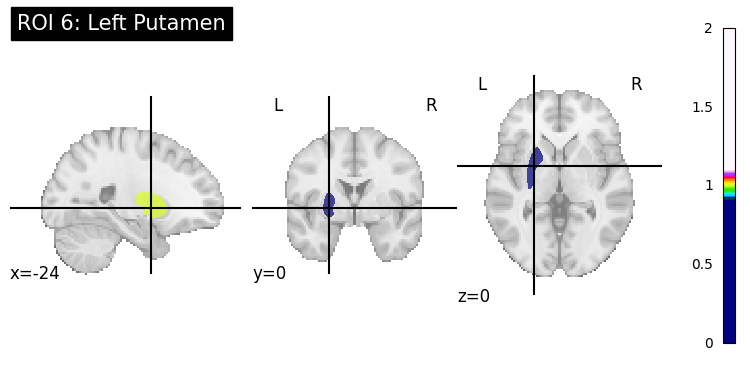

In [6]:
# Seleccionar y visualizar una región del atlas
roi = 6  # Left Putamen

# Crear máscara binaria para esa región
roi_mask = nimg.math_img('a == ' + str(roi), a=atlas_img)

# Visualizar y guardar
display = nplot.plot_roi(roi_mask, title=f"ROI {roi}: {labels[roi]}")

In [7]:
def calculate_roi_volume(nifti_file_path, roi_label):
    # Load the NIfTI file
    img = nib.load(nifti_file_path)
    data = img.get_fdata()

    # Extract the voxel dimensions
    voxel_dimensions = np.prod(img.header.get_zooms())

    # Calculate the volume of the ROI
    roi_volume = np.sum(data == roi_label) * voxel_dimensions

    return roi_volume

In [14]:
atlas_path_local = str(atlas_path)
roi_label = 7  # Left Putamen

volume = calculate_roi_volume(atlas_path_local, roi_label)
print(f"Volumen de {labels[roi_label-1]}: {volume} mm³")

Volumen de Left Putamen: 2133.0 mm³


 <h3> Extraer regiones específicas del cerebro </h3>

Crea una nueva imagen donde solo existen las regiones de interés, todo lo demás queda en cero

In [20]:
def filtering_atlas(base_path, atlas_case_path, labels_of_interest):
    
    atlas = nib.load(atlas_case_path)
    atlas_data = atlas.get_fdata()
    
    # Crear máscara solo con las regiones de interés
    binary_mask_data = np.zeros_like(atlas_data)
    counter = 0
    for label in labels_of_interest:
        counter += 1
        binary_mask_data[atlas_data == label] = counter

    binary_mask_img = nib.Nifti1Image(binary_mask_data, atlas.affine)
    
    # Construir ruta de salida correctamente
    os.makedirs(base_path, exist_ok=True)
    output_path = os.path.join(base_path, "atlas_labels_filtered.nii.gz")
    
    nib.save(binary_mask_img, output_path)
    print(f"  - atlas filtrado guardado: {output_path}")
    
    return output_path

Aplica la máscara al cerebro

In [16]:
def masked_case_roi_atlas(base_path, case_path, atlas_filtered_path, case):
    
    case_registered = nib.load(case_path)
    case_data = case_registered.get_fdata()
    
    mask = nib.load(atlas_filtered_path)
    data2 = mask.get_fdata()

    result_data = case_data * data2
    result_image = nib.Nifti1Image(result_data, case_registered.affine)

    out_path = base_path + "/" + case + "_labels_masked.nii.gz"
    nib.save(result_image, out_path)
    print(f"- saved: {out_path}")

Cerebro enmascarado con atlas completo

In [17]:
def masked_case_with_atlas(atlas_path, case_registered_path, results_dir, case):
    
    atlas = nib.load(atlas_path)
    case_img = nib.load(case_registered_path)

    atlas_data = atlas.get_fdata()
    case_data = case_img.get_fdata()
    
    # Máscara binaria para todas las regiones
    binary_masks_data = np.zeros_like(atlas_data)
    for i in range(atlas_data.shape[-1]):
        binary_masks_data[..., i] = (atlas_data[..., i] > 0).astype(int)

    binary_masks_img = nimg.new_img_like(atlas, binary_masks_data)
    binary_mask_data = binary_masks_img.get_fdata()
    
    masked_image = case_data * binary_mask_data
    masked_case_img = nib.Nifti1Image(masked_image, case_img.affine)
    
    out_path = results_dir + "/" + case + "_masked.nii.gz"
    nib.save(masked_case_img, out_path)
    print(f"- saved: {out_path}")

<h3> Cerebro con todas las regiones visibles</h3>

In [18]:
for modality in ["mri", "spect"]:
    print(f"\n===== Modalidad: {modality} =====")
    
    for case in cases[:1]:  # solo caso de prueba
        print(f"======= case: ======= {case}")
        
        results_dir = str(output_path / group / modality / case)
        files = os.listdir(results_dir)
        
        # Buscar atlas deformado
        nii_files = [f for f in files if f.endswith("elastic_registered_final.nii.gz")]
        atlas_case_path = os.path.join(results_dir, nii_files[0])
        
        # Buscar imagen registrada rígidamente
        nii_files = [f for f in files if f.endswith("rigid_registered.nii.gz")]
        case_registered_path = os.path.join(results_dir, nii_files[0])
        
        # Aplicar máscara con todo el atlas
        masked_case_with_atlas(atlas_case_path, case_registered_path, results_dir, case)

print("\ndone")


===== Modalidad: mri =====
======= case: ======= 3102
- saved: D:\DESCARGAS\replica\preprocesamiento_mri\output\parkinson\mri\3102/3102_masked.nii.gz

===== Modalidad: spect =====
======= case: ======= 3102
- saved: D:\DESCARGAS\replica\preprocesamiento_mri\output\parkinson\spect\3102/3102_masked.nii.gz

done


<h3> Cerebro con parcelaciones - solo visible regiones de interes</h3>

In [21]:
failed_cases = []

for modality in ["mri", "spect"]:
    print(f"\n===== Modalidad: {modality} =====")

    for case in cases[:1]:  # solo caso de prueba
        print(f"======= case: ======= {case}")

        results_dir = str(output_path / group / modality / case)
        files = os.listdir(results_dir)

        # Buscar atlas deformado
        nii_files = [f for f in files if f.endswith("elastic_registered_final.nii.gz")]
        atlas_case_path = os.path.join(results_dir, nii_files[0])

        # Buscar imagen registrada
        nii_files = [f for f in files if f.endswith("rigid_registered.nii.gz")]
        case_registered_path = os.path.join(results_dir, nii_files[0])

        # Definir regiones y carpetas
        parcels = {
            "thalamus":       [4, 15],
            "caudate":        [5, 16],
            "putamen":        [6, 17],
            "brain-stem":     [8],
            "full_pd_regions": [4, 5, 6, 8, 15, 16, 17]
        }

        for parcel_name, to_save in parcels.items():
            print(f"\n  → Parcelación: {parcel_name}")
            current_save_folder = os.path.join(results_dir, "parcelations", parcel_name)
            os.makedirs(current_save_folder, exist_ok=True)

            # Filtrar atlas
            atlas_filtered_path = filtering_atlas(current_save_folder, atlas_case_path, to_save)

            # Aplicar máscara al cerebro
            try:
                masked_case_roi_atlas(current_save_folder, case_registered_path, atlas_filtered_path, case)
            except Exception as e:
                failed_cases.append(case)
                print(f"  ⚠️ case failed: {e}")

print("\nfailed cases:", failed_cases)
print("done")


===== Modalidad: mri =====
======= case: ======= 3102

  → Parcelación: thalamus
  - atlas filtrado guardado: D:\DESCARGAS\replica\preprocesamiento_mri\output\parkinson\mri\3102\parcelations\thalamus\atlas_labels_filtered.nii.gz
- saved: D:\DESCARGAS\replica\preprocesamiento_mri\output\parkinson\mri\3102\parcelations\thalamus/3102_labels_masked.nii.gz

  → Parcelación: caudate
  - atlas filtrado guardado: D:\DESCARGAS\replica\preprocesamiento_mri\output\parkinson\mri\3102\parcelations\caudate\atlas_labels_filtered.nii.gz
- saved: D:\DESCARGAS\replica\preprocesamiento_mri\output\parkinson\mri\3102\parcelations\caudate/3102_labels_masked.nii.gz

  → Parcelación: putamen
  - atlas filtrado guardado: D:\DESCARGAS\replica\preprocesamiento_mri\output\parkinson\mri\3102\parcelations\putamen\atlas_labels_filtered.nii.gz
- saved: D:\DESCARGAS\replica\preprocesamiento_mri\output\parkinson\mri\3102\parcelations\putamen/3102_labels_masked.nii.gz

  → Parcelación: brain-stem
  - atlas filtrado gua